# 04 — Parameter Sensitivity of the SABR Smile

**Goal.** For each of the four SABR parameters $(\alpha, \beta, \rho, \nu)$, show *how* it deforms the implied-volatility smile and quantify the effect. This delivers the *Parameter Sensitivity* analysis described on slides 8–9 of the outline.

**Plan.**
1. Baseline smile $\sigma(K)$ (reproduces Hagan fig. 3.3 shape).
2. $\alpha$ — volatility **level**.
3. $\beta$ — **backbone** (static shape + $\sigma_{ATM}$ vs $F$).
4. $\rho$ — **skew**.
5. $\nu$ — **smile curvature**.
6. Joint $(\rho, \nu)$ heatmap.
7. Term-structure: smile flattening with $T$.
8. Quantitative summary table.

The smile is summarized by three ATM descriptors
$$\text{level} = \sigma(F,F,T),\quad \text{slope} = \partial_{\ln K}\sigma|_{K=F},\quad \text{curv.} = \partial^2_{\ln K}\sigma|_{K=F}.$$

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

from src.sabr import sabr_vol, sabr_vol_atm
from src.sensitivity import (
    atm_level, atm_slope, atm_curvature,
    backbone, alpha_for_target_atm,
)


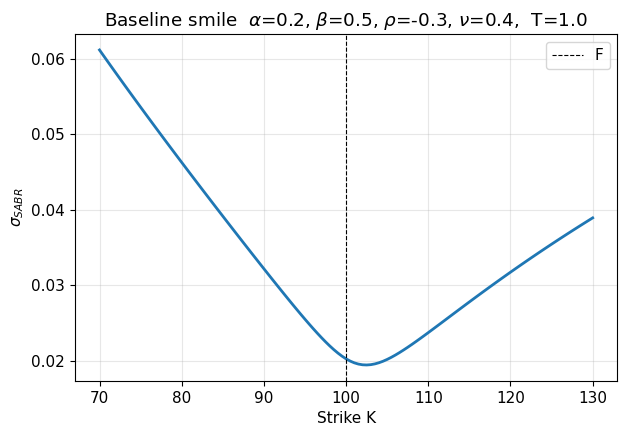

ATM level     = 0.02022
ATM slope     = -0.06572
ATM curvature = 2.32140


In [2]:
# --- Baseline market state (equity-index-like) ---
F0 = 100.0        # forward
T0 = 1.0          # time to expiry (years)
alpha0 = 0.20     # SABR alpha
beta0  = 0.5      # elasticity
rho0   = -0.30    # correlation
nu0    = 0.40     # vol-of-vol

Ks = np.linspace(70, 130, 121)
base_iv = sabr_vol(Ks, F0, T0, alpha0, beta0, rho0, nu0)

plt.plot(Ks, base_iv, lw=2)
plt.axvline(F0, color='k', lw=0.8, ls='--', label='F')
plt.xlabel('Strike K'); plt.ylabel(r'$\sigma_{SABR}$')
plt.title(rf'Baseline smile  $\alpha$={alpha0}, $\beta$={beta0}, '
          rf'$\rho$={rho0}, $\nu$={nu0},  T={T0}')
plt.legend(); plt.show()

print(f'ATM level     = {atm_level(F0,T0,alpha0,beta0,rho0,nu0):.5f}')
print(f'ATM slope     = {atm_slope(F0,T0,alpha0,beta0,rho0,nu0):.5f}')
print(f'ATM curvature = {atm_curvature(F0,T0,alpha0,beta0,rho0,nu0):.5f}')

---
## 1. $\alpha$ — volatility level

$\alpha$ sets the overall level of the smile; it enters as a multiplicative factor in Hagan (2.17a). Expect an approximately rigid vertical translation.

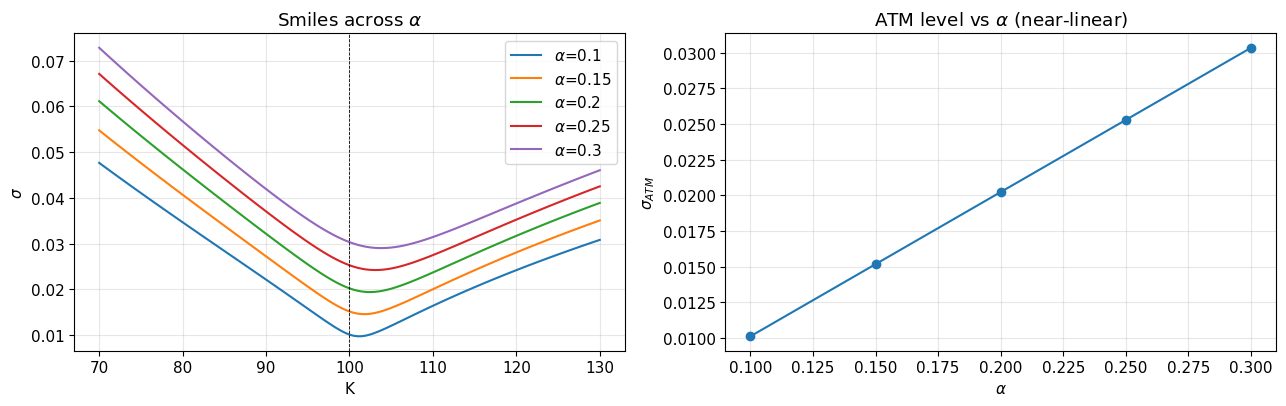

In [3]:
alpha_grid = [0.10, 0.15, 0.20, 0.25, 0.30]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

for a in alpha_grid:
    ax[0].plot(Ks, sabr_vol(Ks, F0, T0, a, beta0, rho0, nu0), label=rf'$\alpha$={a}')
ax[0].axvline(F0, color='k', lw=0.6, ls='--')
ax[0].set_xlabel('K'); ax[0].set_ylabel(r'$\sigma$')
ax[0].set_title(r'Smiles across $\alpha$'); ax[0].legend()

levels = [atm_level(F0,T0,a,beta0,rho0,nu0) for a in alpha_grid]
ax[1].plot(alpha_grid, levels, 'o-')
ax[1].set_xlabel(r'$\alpha$'); ax[1].set_ylabel(r'$\sigma_{ATM}$')
ax[1].set_title(r'ATM level vs $\alpha$ (near-linear)')
plt.tight_layout(); plt.show()

---
## 2. $\beta$ — backbone

$\beta$ has two distinct effects:
* **Shape** of the smile at a fixed forward: different $\beta$   produce different curvature/wing behaviour.
* **Backbone**: as $F$ moves, the ATM vol traces   $\sigma_{ATM} \sim \alpha / F^{\,1-\beta}$ (Hagan 2.15).
  $\beta = 1$ (lognormal) ⇒ flat backbone — equity/FX style.
  $\beta = 0$ (normal)  ⇒ $\sigma_{ATM} \propto 1/F$ — rate style.

We compare **$\beta \in \{0, 0.5, 1\}$** with $\alpha$ re-scaled so that the ATM volatility is identical across $\beta$ (apples-to-apples comparison).

In [4]:
beta_grid = [0.0, 0.5, 1.0]
target_atm = 0.20

alphas = {b: alpha_for_target_atm(F0, T0, b, rho0, nu0, target_atm) for b in beta_grid}
for b, a in alphas.items():
    atm = atm_level(F0, T0, a, b, rho0, nu0)
    print(f'beta={b}:  alpha={a:.4g},  ATM={atm:.6f}')

beta=0.0:  alpha=19.74,  ATM=0.200000
beta=0.5:  alpha=1.982,  ATM=0.200000
beta=1.0:  alpha=0.1989,  ATM=0.200000


### 2a. Static smile shape across $\beta$

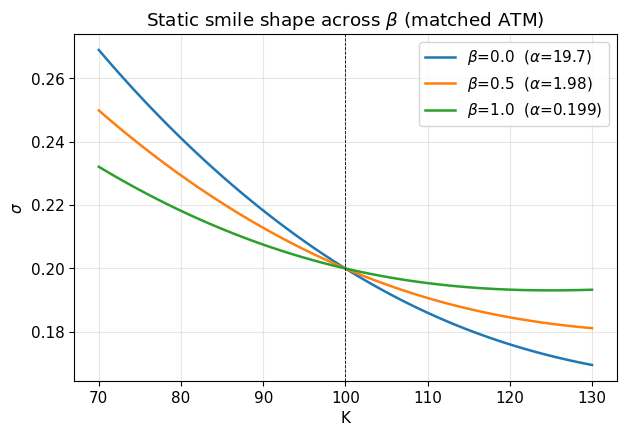

In [5]:
plt.figure()
for b in beta_grid:
    plt.plot(Ks, sabr_vol(Ks, F0, T0, alphas[b], b, rho0, nu0),
             label=rf'$\beta$={b}  ($\alpha$={alphas[b]:.3g})', lw=1.8)
plt.axvline(F0, color='k', lw=0.6, ls='--')
plt.xlabel('K'); plt.ylabel(r'$\sigma$')
plt.title(r'Static smile shape across $\beta$ (matched ATM)')
plt.legend(); plt.show()

### 2b. Backbone — $\sigma_{ATM}$ as $F$ moves
For each $\beta$, freeze $(\alpha, \rho, \nu)$ at the matched-ATM values above and sweep $F$. The resulting locus is the **backbone**.

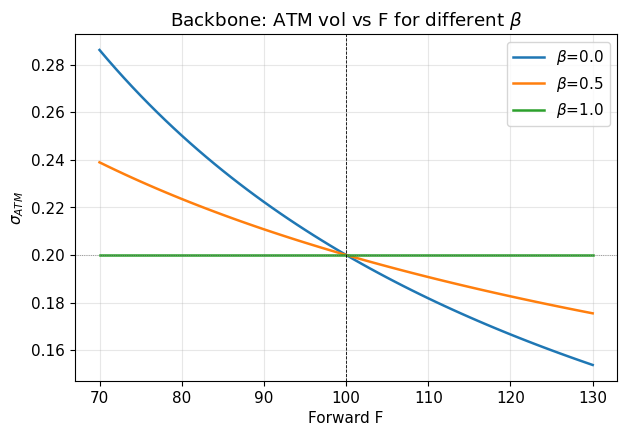

In [6]:
F_grid = np.linspace(70, 130, 61)
plt.figure()
for b in beta_grid:
    bb = backbone(F_grid, T0, alphas[b], b, rho0, nu0)
    plt.plot(F_grid, bb, label=rf'$\beta$={b}', lw=1.8)
plt.axvline(F0, color='k', lw=0.6, ls='--')
plt.axhline(target_atm, color='grey', lw=0.6, ls=':')
plt.xlabel('Forward F'); plt.ylabel(r'$\sigma_{ATM}$')
plt.title(r'Backbone: ATM vol vs F for different $\beta$')
plt.legend(); plt.show()

**Reading the plot.**
* $\beta = 1$: essentially flat — classical Black/lognormal.
* $\beta = 0$: steep negative slope — normal model; vol inversely scales with F.
* $\beta = 0.5$: intermediate; the shape used in the paper for interest-rate smiles.

On slide 4 of the outline the point is that **local volatility** locks the backbone into a deterministic function of F, giving the *wrong* direction empirically; SABR, by contrast, is a stochastic-vol model where the backbone shape is controlled by $\beta$ and the correlation $\rho$ separately.

---
## 3. $\rho$ — skew

$\rho$ controls the correlation between the forward and its stochastic vol. Empirically, equity indices have $\rho < 0$ (vol rises when the market falls), producing a **negative ATM slope**.

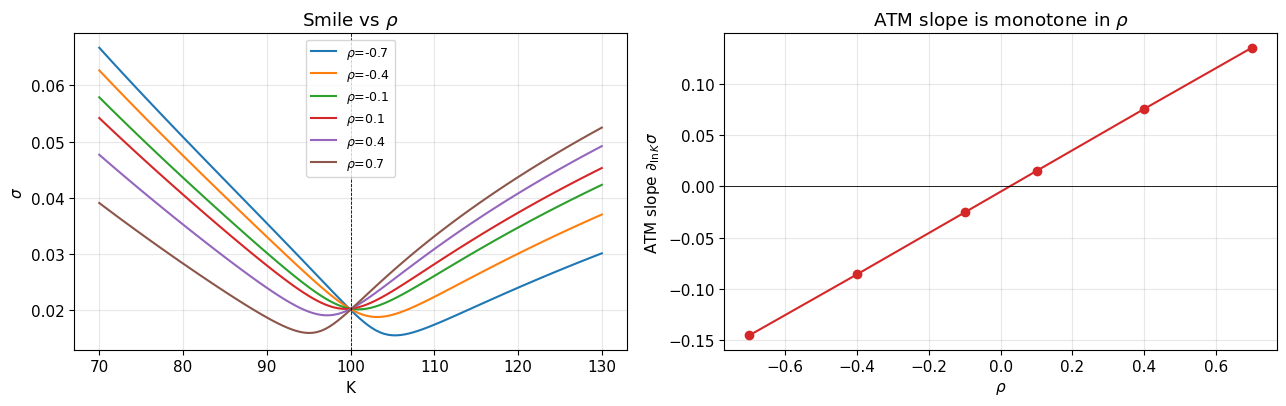

In [7]:
rho_grid = [-0.7, -0.4, -0.1, 0.1, 0.4, 0.7]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for r in rho_grid:
    ax[0].plot(Ks, sabr_vol(Ks, F0, T0, alpha0, beta0, r, nu0), label=rf'$\rho$={r}')
ax[0].axvline(F0, color='k', lw=0.6, ls='--')
ax[0].set_xlabel('K'); ax[0].set_ylabel(r'$\sigma$')
ax[0].set_title(r'Smile vs $\rho$'); ax[0].legend(fontsize=9)

slopes = [atm_slope(F0,T0,alpha0,beta0,r,nu0) for r in rho_grid]
ax[1].plot(rho_grid, slopes, 'o-', color='C3')
ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_xlabel(r'$\rho$'); ax[1].set_ylabel(r'ATM slope $\partial_{\ln K}\sigma$')
ax[1].set_title(r'ATM slope is monotone in $\rho$')
plt.tight_layout(); plt.show()

---
## 4. $\nu$ — smile curvature (vol-of-vol)

$\nu$ controls how variable the stochastic vol is. Larger $\nu$ ⇒ fatter wings ⇒ higher ATM **curvature**.

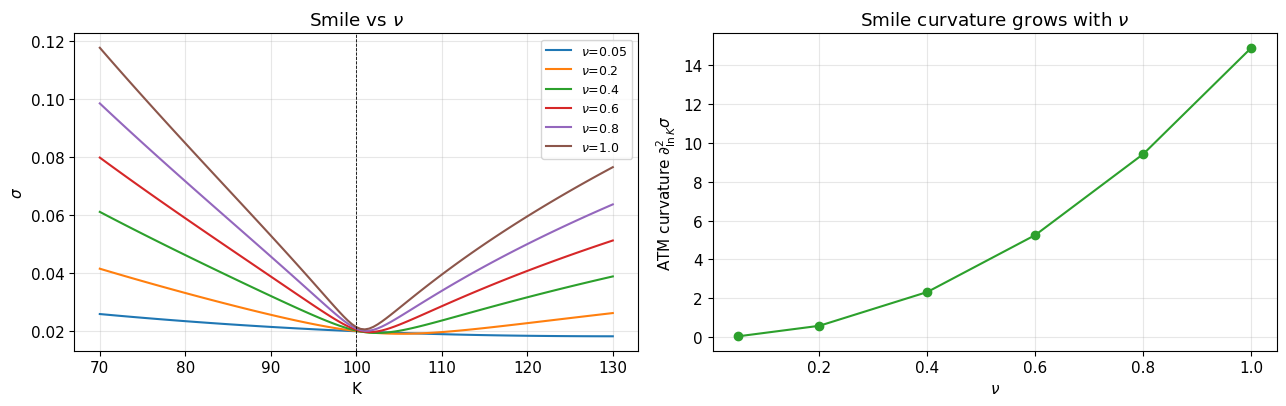

In [8]:
nu_grid = [0.05, 0.20, 0.40, 0.60, 0.80, 1.00]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for n in nu_grid:
    ax[0].plot(Ks, sabr_vol(Ks, F0, T0, alpha0, beta0, rho0, n), label=rf'$\nu$={n}')
ax[0].axvline(F0, color='k', lw=0.6, ls='--')
ax[0].set_xlabel('K'); ax[0].set_ylabel(r'$\sigma$')
ax[0].set_title(r'Smile vs $\nu$'); ax[0].legend(fontsize=9)

curvs = [atm_curvature(F0,T0,alpha0,beta0,rho0,n) for n in nu_grid]
ax[1].plot(nu_grid, curvs, 'o-', color='C2')
ax[1].set_xlabel(r'$\nu$'); ax[1].set_ylabel(r'ATM curvature $\partial^2_{\ln K}\sigma$')
ax[1].set_title(r'Smile curvature grows with $\nu$')
plt.tight_layout(); plt.show()

---
## 5. Joint $(\rho, \nu)$ effect

Two heatmaps over a $(\rho, \nu)$ grid: ATM **slope** (skew) and ATM **curvature** (smile). Confirms that $\rho$ dominates the slope and $\nu$ dominates the curvature, with mild cross-terms.

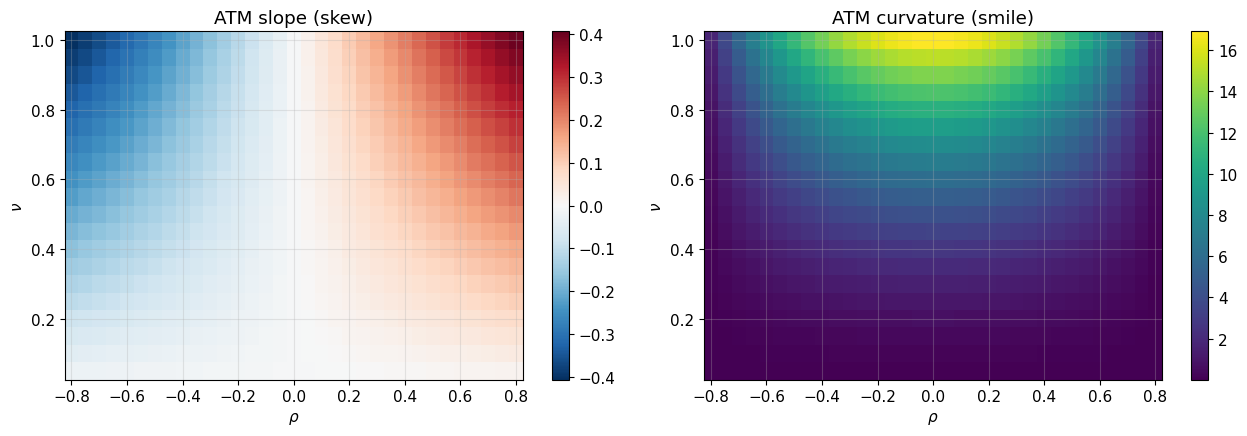

In [9]:
rho_ax = np.linspace(-0.8, 0.8, 33)
nu_ax  = np.linspace(0.05, 1.0, 20)
RR, NN = np.meshgrid(rho_ax, nu_ax)
SLOPE = np.vectorize(lambda r, n: atm_slope(F0,T0,alpha0,beta0,r,n))(RR, NN)
CURV  = np.vectorize(lambda r, n: atm_curvature(F0,T0,alpha0,beta0,r,n))(RR, NN)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
im0 = ax[0].pcolormesh(rho_ax, nu_ax, SLOPE, shading='auto', cmap='RdBu_r',
                       vmin=-abs(SLOPE).max(), vmax=abs(SLOPE).max())
ax[0].set_xlabel(r'$\rho$'); ax[0].set_ylabel(r'$\nu$')
ax[0].set_title('ATM slope (skew)'); plt.colorbar(im0, ax=ax[0])

im1 = ax[1].pcolormesh(rho_ax, nu_ax, CURV, shading='auto', cmap='viridis')
ax[1].set_xlabel(r'$\rho$'); ax[1].set_ylabel(r'$\nu$')
ax[1].set_title('ATM curvature (smile)'); plt.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

---
## 6. Term structure

With all SABR parameters held fixed, sweep the expiry $T$. SABR's leading-order correction in Hagan (2.17) is $\mathcal{O}(T)$, so the smile flattens as $T$ grows.

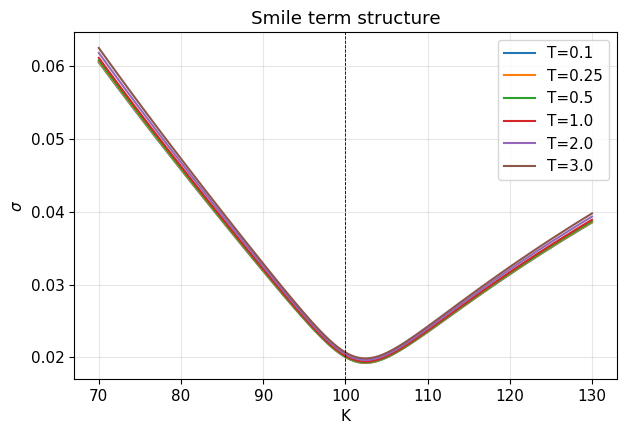

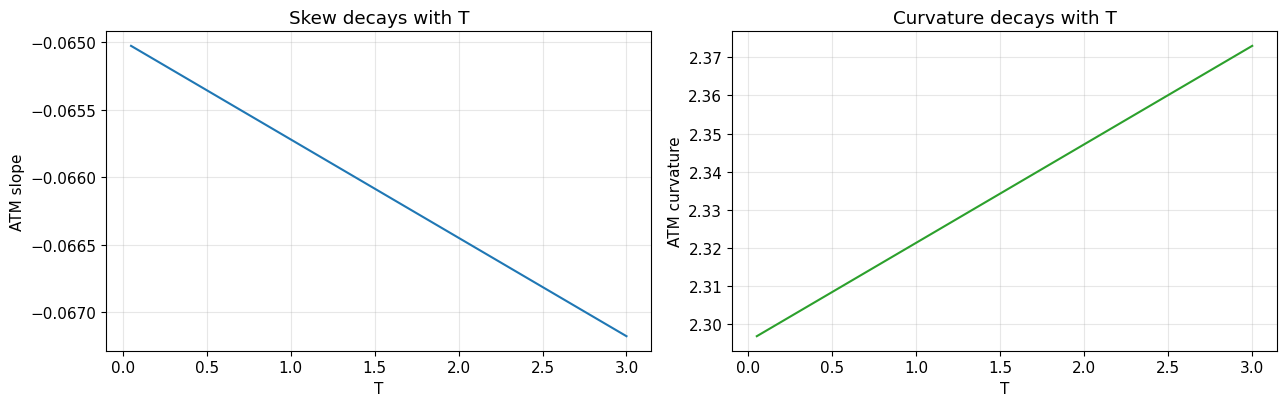

In [10]:
T_grid = [0.1, 0.25, 0.5, 1.0, 2.0, 3.0]
plt.figure()
for T_ in T_grid:
    plt.plot(Ks, sabr_vol(Ks, F0, T_, alpha0, beta0, rho0, nu0), label=f'T={T_}')
plt.axvline(F0, color='k', lw=0.6, ls='--')
plt.xlabel('K'); plt.ylabel(r'$\sigma$')
plt.title('Smile term structure')
plt.legend(); plt.show()

# Quantitative: slope and curvature as functions of T
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
Ts = np.linspace(0.05, 3.0, 60)
sls = [atm_slope(F0,T,alpha0,beta0,rho0,nu0) for T in Ts]
cvs = [atm_curvature(F0,T,alpha0,beta0,rho0,nu0) for T in Ts]
ax[0].plot(Ts, sls); ax[0].set_xlabel('T'); ax[0].set_ylabel('ATM slope')
ax[0].set_title('Skew decays with T')
ax[1].plot(Ts, cvs, color='C2'); ax[1].set_xlabel('T'); ax[1].set_ylabel('ATM curvature')
ax[1].set_title('Curvature decays with T')
plt.tight_layout(); plt.show()

---
## 7. Quantitative summary

In [11]:
# Sweep one parameter at a time around the baseline; report descriptors.
rows = []
def describe(name, val, a, b, r, n):
    rows.append({
        'varied': name,
        'value' : val,
        'ATM level'    : atm_level(F0, T0, a, b, r, n),
        'ATM slope'    : atm_slope(F0, T0, a, b, r, n),
        'ATM curvature': atm_curvature(F0, T0, a, b, r, n),
    })

for a in alpha_grid:  describe('alpha', a, a, beta0, rho0, nu0)
for b in beta_grid:   describe('beta' , b, alphas[b], b, rho0, nu0)
for r in rho_grid:    describe('rho'  , r, alpha0, beta0, r, nu0)
for n in nu_grid:     describe('nu'   , n, alpha0, beta0, rho0, n)

df = pd.DataFrame(rows)
df

,varied,value,ATM level,ATM slope,ATM curvature
0,alpha,0.10,0.010114,-0.063175,4.564742
1,alpha,0.15,0.015170,-0.064454,3.081765
2,alpha,0.20,0.020225,-0.065720,2.321405
3,alpha,0.25,0.025279,-0.066981,1.860963
4,alpha,0.30,0.030333,-0.068241,1.552679
5,beta,0.00,0.200000,-0.161110,0.270953
6,beta,0.50,0.200000,-0.110431,0.243018
7,beta,1.00,0.200000,-0.060334,0.233229
8,rho,-0.70,0.020057,-0.145398,0.736656
9,rho,-0.40,0.020195,-0.085815,2.046641


---
## Summary

| Parameter | Dominant effect | Observed signature |
|---|---|---|
| $\alpha$ | level | ATM level $\uparrow$ roughly linearly in $\alpha$ |
| $\beta$  | backbone | Flat ($\beta{=}1$) / decreasing ($\beta{<}1$) ATM vs $F$ |
| $\rho$   | skew  | ATM slope is monotone in $\rho$; $\rho{<}0$ ⇒ negative skew |
| $\nu$    | smile | ATM curvature increases with $\nu$ |

Matches slide 8 in the outline qualitatively and gives the numerical backing for the parameter-intuition story told in the presentation. These descriptors will also be the **calibration targets** in Module 4: $\rho$ is pinned by the observed ATM skew, $\nu$ by the observed curvature, $\alpha$ by the ATM level; $\beta$ is usually fixed by market convention (0.5 for rates, often ≈1 for equity indices).